In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_csv("loan_prediction_dataset.csv")

# Clean column names (VERY IMPORTANT - fixes space issue)
df.columns = df.columns.str.strip()

In [3]:
print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (4269, 13)
   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value loan_status  
0                 17600000             227

In [4]:
print(df.isnull().sum())

# Drop if any missing values exist
df = df.dropna()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [5]:
df = df.drop("loan_id", axis=1)

In [6]:
le = LabelEncoder()

df["education"] = le.fit_transform(df["education"])
df["self_employed"] = le.fit_transform(df["self_employed"])
df["loan_status"] = le.fit_transform(df["loan_status"])

In [7]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (4269, 11)
y shape: (4269,)


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (important for visualization)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

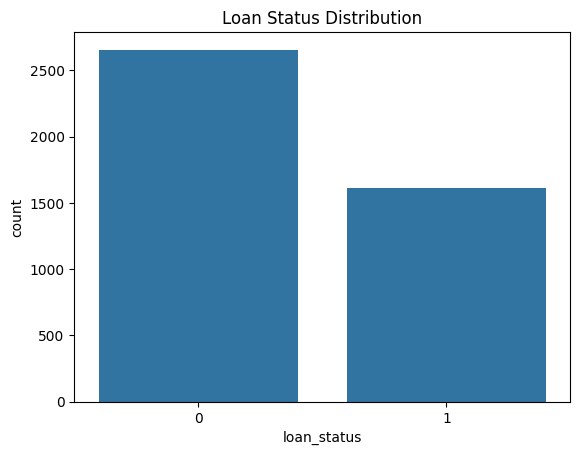

In [9]:
plt.figure()
sns.countplot(x=y)
plt.title("Loan Status Distribution")
plt.show()

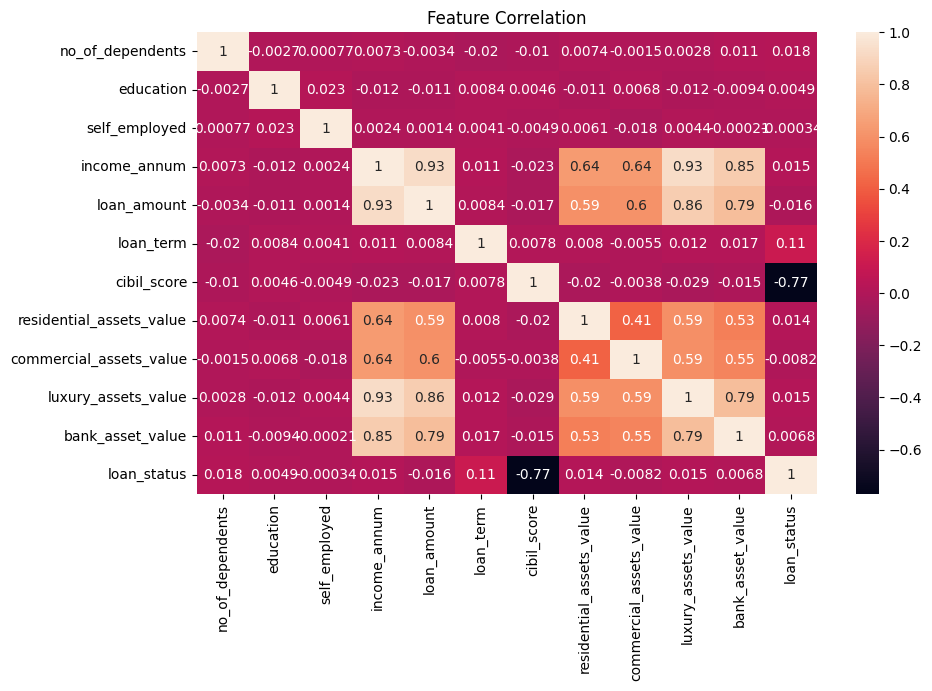

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

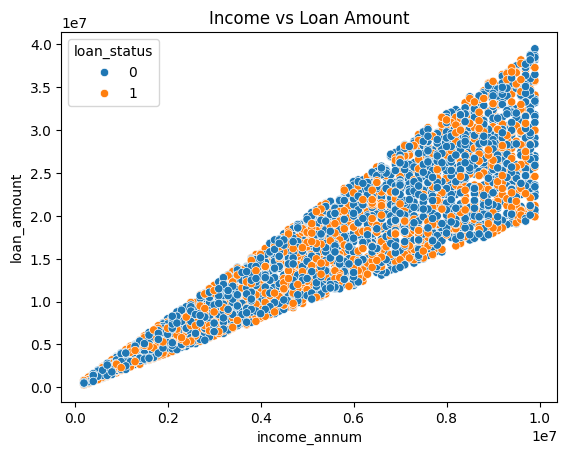

In [11]:
plt.figure()
sns.scatterplot(x=df["income_annum"], y=df["loan_amount"], hue=y)
plt.title("Income vs Loan Amount")
plt.show()

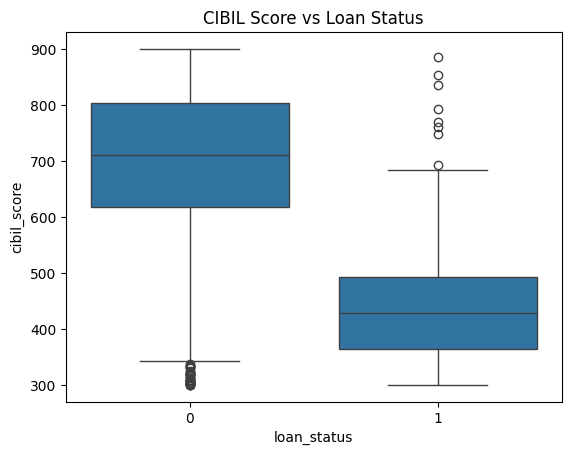

In [12]:
plt.figure()
sns.boxplot(x=y, y=df["cibil_score"])
plt.title("CIBIL Score vs Loan Status")
plt.show()

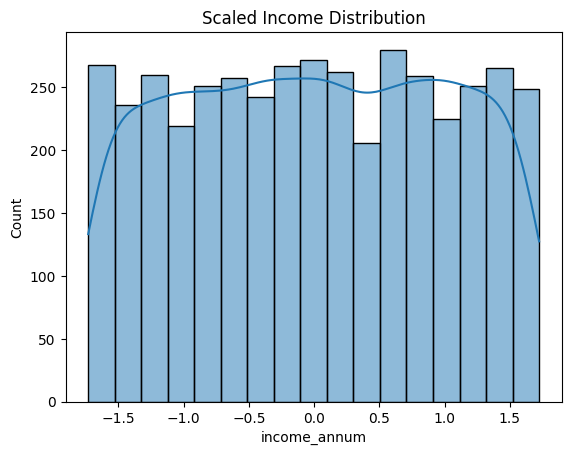

In [13]:
plt.figure()
sns.histplot(X_scaled["income_annum"], kde=True)
plt.title("Scaled Income Distribution")
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3415, 11)
Test shape: (854, 11)


In [15]:
#Logistics Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [16]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
#XG Boost
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

C:\Users\diyaj\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:183: UserWarning: [21:22:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [18]:
#Evaluation
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [19]:
#Comparision
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, "XGBoost")


--- Logistic Regression ---
Accuracy: 0.905152224824356
ROC-AUC: 0.8969421759128883
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854


--- Random Forest ---
Accuracy: 0.9824355971896955
ROC-AUC: 0.9789730592321412
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       536
           1       0.99      0.97      0.98       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854


--- XGBoost ---
Accuracy: 0.9824355971896955
ROC-AUC: 0.9802520416784005
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       53

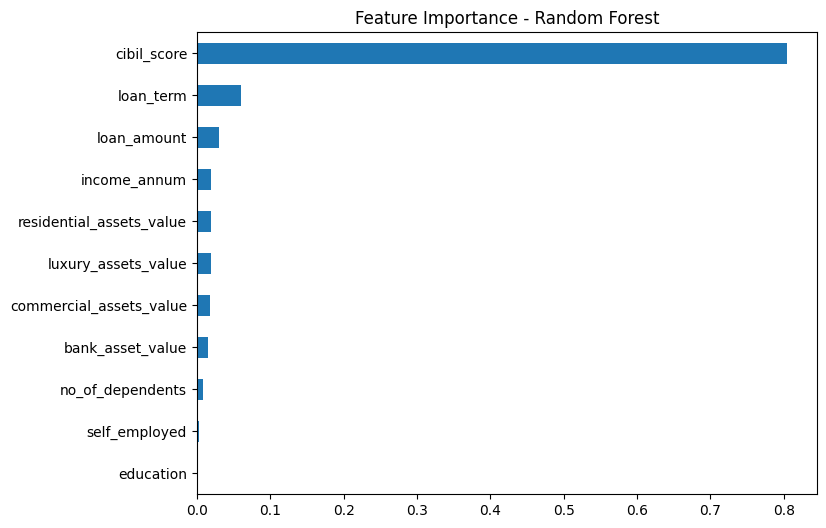

In [20]:
#Feature Importance to check dependencies(For Random Forest)
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - Random Forest")
plt.show()

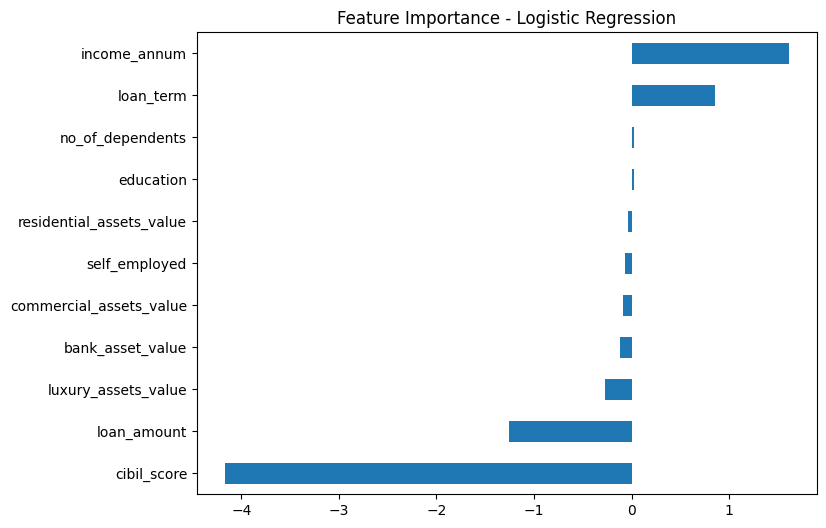

In [21]:
#Feature Evaluation for Logistic Regression
coef = pd.Series(lr.coef_[0], index=X.columns)
coef.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - Logistic Regression")
plt.show()


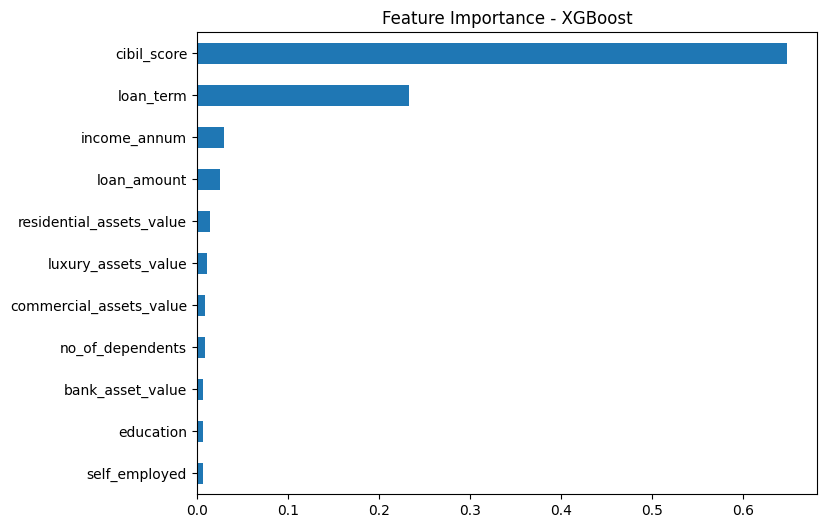

In [22]:
#Conclusioon :“Logistic regression analysis shows that higher CIBIL scores significantly reduce the probability of loan rejection, while longer loan terms increase rejection risk.”
#feature importance of xgboost
import matplotlib.pyplot as plt
import pandas as pd

xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns)

xgb_importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - XGBoost")
plt.show()

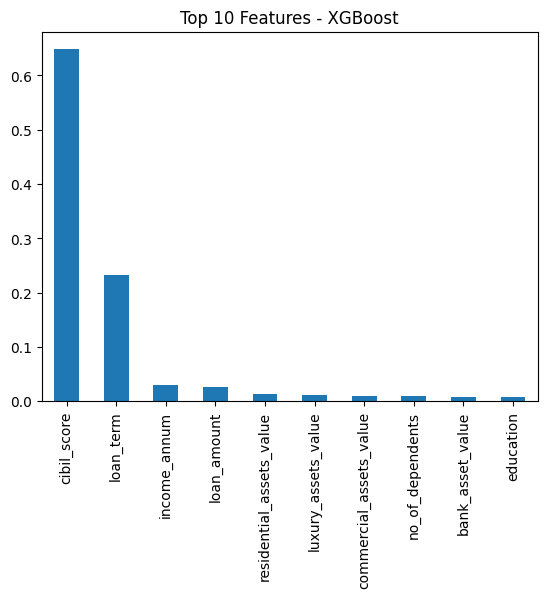

In [23]:
xgb_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Features - XGBoost")
plt.show()

In [24]:
df.corr()['loan_status'].sort_values(ascending=False)

loan_status                 1.000000
loan_term                   0.113036
no_of_dependents            0.018114
luxury_assets_value         0.015465
income_annum                0.015189
residential_assets_value    0.014367
bank_asset_value            0.006778
education                   0.004918
self_employed              -0.000345
commercial_assets_value    -0.008246
loan_amount                -0.016150
cibil_score                -0.770518
Name: loan_status, dtype: float64

In [25]:
#Experiment 1 :since cibil score is deciding factor so temporarily removing it and then rechcking the accuracy of models for research purpose
X_new = X.drop(columns=['cibil_score'])

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

xgb_new = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_new.fit(X_train_new, y_train_new)

y_pred_new = xgb_new.predict(X_test_new)

from sklearn.metrics import accuracy_score
print("Accuracy without CIBIL:", accuracy_score(y_test_new, y_pred_new))

C:\Users\diyaj\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:183: UserWarning: [21:22:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy without CIBIL: 0.5655737704918032


In [26]:
# Logistic Regression without CIBIL
lr_new = LogisticRegression()
lr_new.fit(X_train_new, y_train_new)
y_pred_lr_new = lr_new.predict(X_test_new)

print("LR Accuracy without CIBIL:", accuracy_score(y_test_new, y_pred_lr_new))

LR Accuracy without CIBIL: 0.6288056206088993


In [27]:
# Random Forest without CIBIL
rf_new = RandomForestClassifier()
rf_new.fit(X_train_new, y_train_new)
y_pred_rf_new = rf_new.predict(X_test_new)

print("RF Accuracy without CIBIL:", accuracy_score(y_test_new, y_pred_rf_new))

RF Accuracy without CIBIL: 0.5749414519906323


In [28]:
#Experment 2:balancing original dataset to check the difference its making

df = pd.read_csv("loan_prediction_dataset.csv")

# remove garbage column again
if ' ' in df.columns:
    df = df.drop(columns=[' '])

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [30]:
from imblearn.over_sampling import SMOTE

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

In [33]:
#again model testing
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Probabilities (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred
    
    # Results
    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [34]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

In [35]:
evaluate_model(lr, X_train, X_test, y_train, y_test, "Logistic Regression")

evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest")

evaluate_model(xgb, X_train, X_test, y_train, y_test, "XGBoost")


===== Logistic Regression =====
Accuracy: 0.7695202257761053
ROC-AUC: 0.8641050770181308

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.86      0.78       502
           1       0.84      0.69      0.76       561

    accuracy                           0.77      1063
   macro avg       0.78      0.77      0.77      1063
weighted avg       0.78      0.77      0.77      1063


Confusion Matrix:
[[430  72]
 [173 388]]

===== Random Forest =====
Accuracy: 0.9783631232361242
ROC-AUC: 0.9983009139910944

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       502
           1       0.99      0.97      0.98       561

    accuracy                           0.98      1063
   macro avg       0.98      0.98      0.98      1063
weighted avg       0.98      0.98      0.98      1063


Confusion Matrix:
[[496   6]
 [ 17 544]]


C:\Users\diyaj\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:183: UserWarning: [21:22:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost =====
Accuracy: 0.9830667920978363
ROC-AUC: 0.998817563968724

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       502
           1       0.99      0.97      0.98       561

    accuracy                           0.98      1063
   macro avg       0.98      0.98      0.98      1063
weighted avg       0.98      0.98      0.98      1063


Confusion Matrix:
[[499   3]
 [ 15 546]]


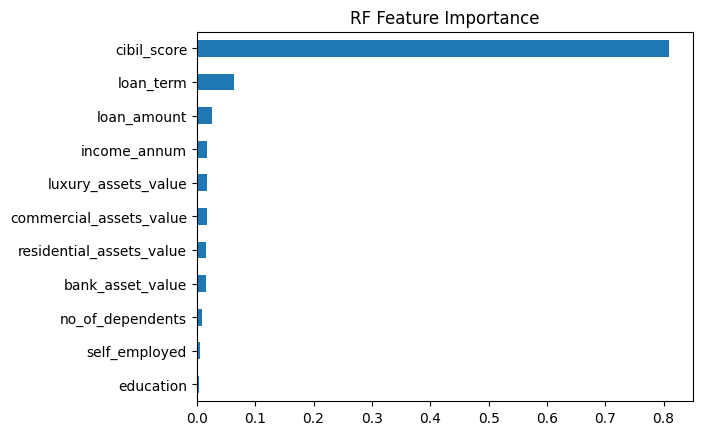

In [36]:
#again checking feature dependencies for rf
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title("RF Feature Importance")
plt.show()

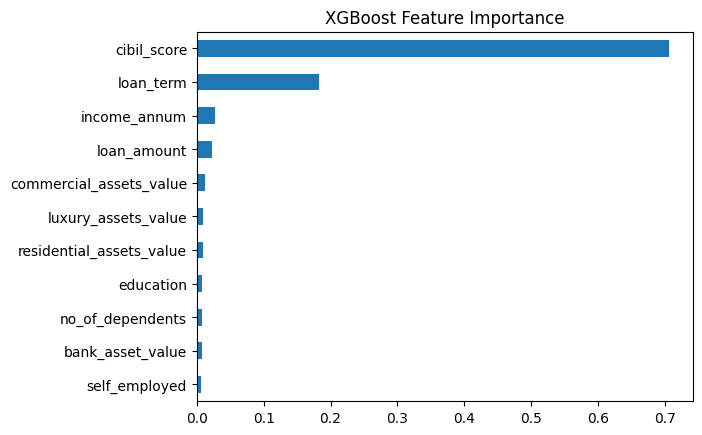

In [37]:
#for xgboost
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns)
xgb_importance.sort_values().plot(kind='barh')
plt.title("XGBoost Feature Importance")
plt.show()

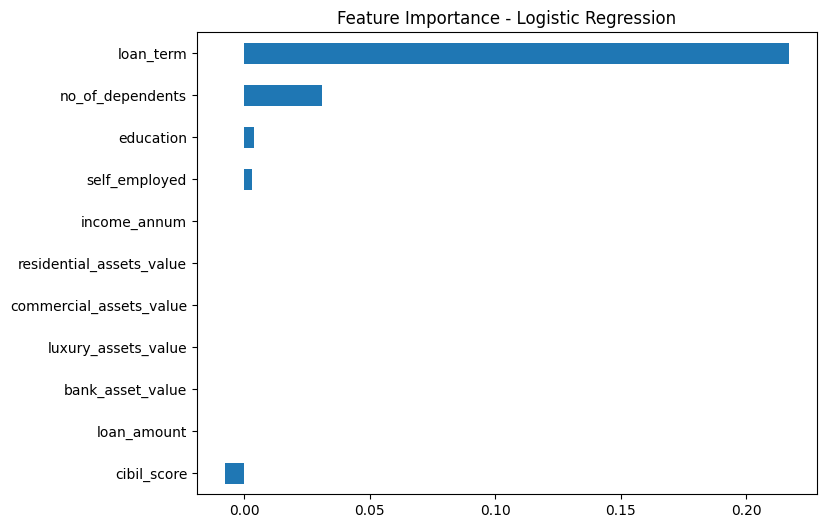

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Get coefficients
coef = pd.Series(lr.coef_[0], index=X.columns)

# Sort and plot
coef.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance - Logistic Regression")
plt.show()

In [39]:
import shap
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

In [40]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

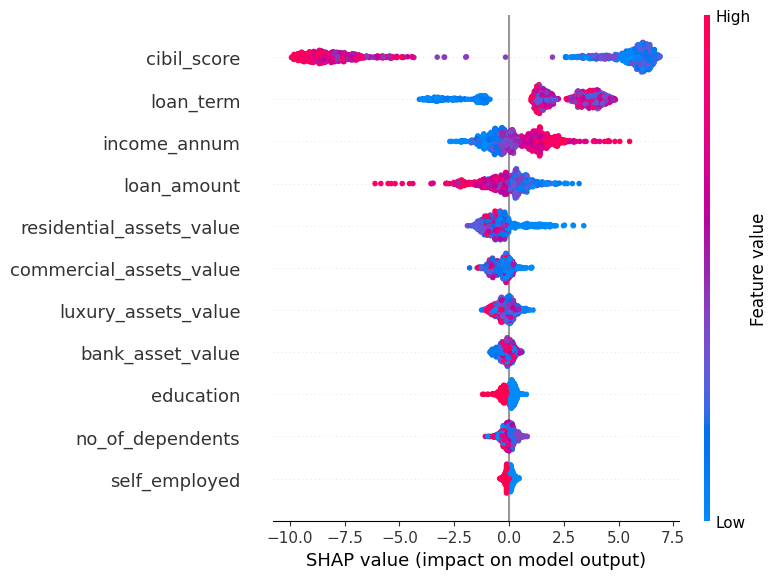

In [41]:
shap.summary_plot(shap_values, X_test)

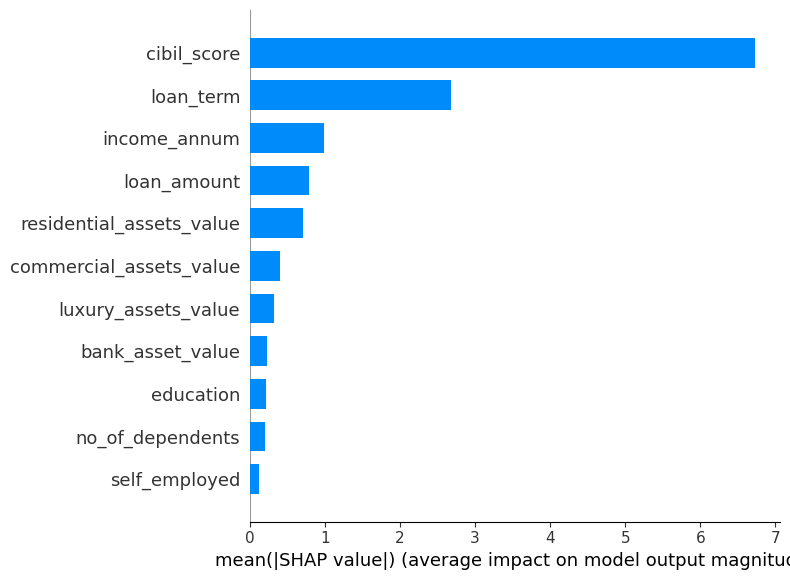

In [42]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [43]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

In [44]:
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    mode='classification'
)

In [45]:
i = 0  # index of test sample

exp = explainer_lime.explain_instance(
    X_test.iloc[i].values,
    xgb.predict_proba,
    num_features=10
)

exp.show_in_notebook(show_table=True)

In [46]:
import joblib

In [47]:
joblib.dump(xgb, "loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [48]:
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']